In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
pd.__version__

'2.3.3'

In [ ]:
data = pd.read_csv(
    "./data/raw/anuario_aforos/GUADALQUIVIR_estaf.csv", encoding="latin-1", sep=";", decimal="."
)

In [11]:
data.columns

Index(['indroea', 'lugar', 'comentario', 'serv', 'suprest', 'suprcnc',
       'hoja_id', 'alti', 'altimax', 'naa', 'naam', 'naai', 'num_cuenca',
       'muni_id', 'xutm', 'yutm', 'xutm30', 'yutm30', 'long', 'lat',
       'longwgs84', 'latwgs84', 'observ1', 'observ2', 'observ3', 'observ4',
       'observ5', 'xetrs89', 'yetrs89', 'cod_saih'],
      dtype='object')

In [15]:
print(data[["indroea", "lugar"]].to_string())

     indroea                                lugar
0       5001  ARROYO MARIA                       
1       5002  PUENTE CERRADA                     
2       5003  PEDRO MARIN (CALANCHA)             
3       5004  MENGIBAR                           
4       5006  PEÑAFLOR                           
5       5007  PALMA DEL RIO                      
6       5008  CANTILLANA                         
7       5012  DOCTOR, EL                         
8       5014  BALLESTEROS                        
9       5016  VALCHILLON                         
10      5017  ORIGINAL, LA                       
11      5018  MANZANO                            
12      5019  NEGRATIN                           
13      5020  PINOS-GENIL                        
14      5021  QUENTAR                            
15      5023  POSITO                             
16      5024  HORNO DEL VIDRIO                   
17      5025  LLANO DE VELA                      
18      5027  RUINAS DE PUENTE                   


In [ ]:
caudal = pd.read_csv(
    "./data/raw/anuario_aforos/GUADALQUIVIR_afliq.csv", encoding="latin-1", sep=";", decimal="."
)

In [18]:
mask = caudal["indroea"] == 5020

In [20]:
pinos = caudal.loc[mask, ["fecha", "caudal"]]

In [24]:
pinos["fecha"] = pd.to_datetime(pinos["fecha"], format="%d/%m/%Y")

In [25]:
pinos.dtypes

fecha     datetime64[ns]
caudal           float64
dtype: object

In [34]:
ts = pd.Series(pinos["caudal"].values, index=pd.DatetimeIndex(pinos["fecha"].values))

In [38]:
ts.index

DatetimeIndex(['1913-01-01', '1913-01-02', '1913-01-03', '1913-01-04',
               '1913-01-05', '1913-01-06', '1913-01-07', '1913-01-08',
               '1913-01-09', '1913-01-10',
               ...
               '2021-09-21', '2021-09-22', '2021-09-23', '2021-09-24',
               '2021-09-25', '2021-09-26', '2021-09-27', '2021-09-28',
               '2021-09-29', '2021-09-30'],
              dtype='datetime64[ns]', length=15348, freq=None)

In [39]:
ts.values

array([  nan,   nan,   nan, ..., 0.346, 0.336, 0.336], shape=(15348,))

In [40]:
ts.isna().sum()

np.int64(1021)

In [41]:
ts.shape

(15348,)

In [43]:
ts.index.diff().max()

Timedelta('22555 days 00:00:00')

In [ ]:
mask1 = ts.index.diff() > pd.Timedelta(days=1)

In [51]:
ts[mask1]

1914-04-22      NaN
1914-12-15      NaN
1976-10-01    0.120
1982-08-01    1.350
1992-10-01    0.048
1993-11-24    0.014
1995-07-01    0.007
2010-10-01    0.236
dtype: float64

In [59]:
ts["1980":"2005"]

1980-01-01    1.600
1980-01-02    1.600
1980-01-03    1.600
1980-01-04    1.525
1980-01-05    1.525
              ...  
2005-12-27    0.066
2005-12-28    0.066
2005-12-29    0.066
2005-12-30    0.066
2005-12-31    0.066
Length: 8046, dtype: float64

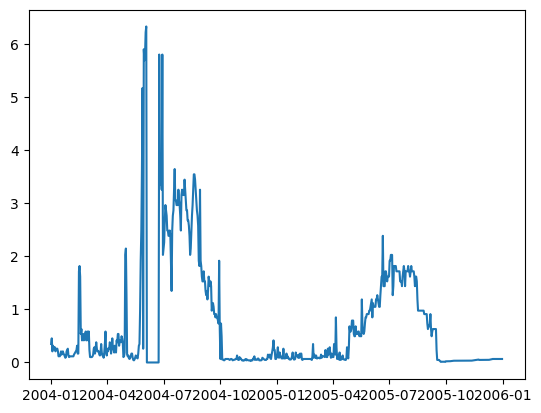

In [65]:
plt.plot(ts["2004":"2005"])

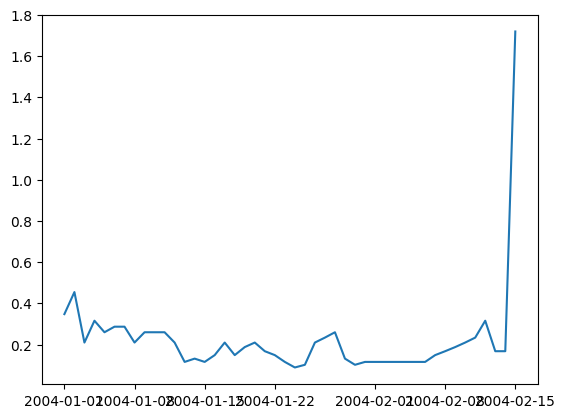

In [67]:
plt.plot(ts["2004-01-01":"2004-02-15"])